In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



In [3]:
df = pd.read_csv('example_data_1_PHYS_433_533.csv')
print(df)

      f_res  max_power_dBm
0      3000          -54.0
1      3002          -54.1
2      3004          -54.0
3      3006          -53.9
4      3008          -53.8
...     ...            ...
996    4992          -63.8
997    4994          -63.3
998    4996          -63.3
999    4998          -63.8
1000   5000          -64.2

[1001 rows x 2 columns]


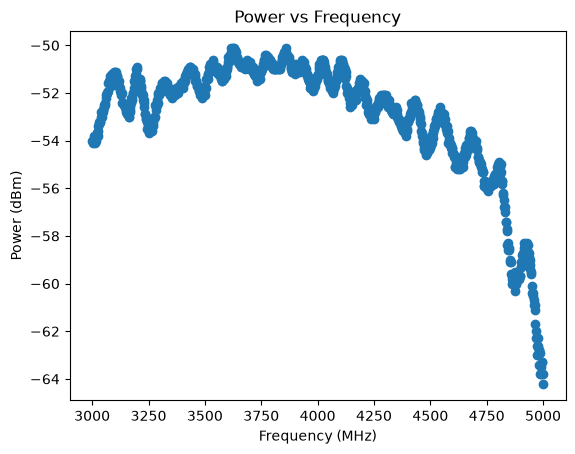

In [5]:
frequency = df['f_res']
power_dBm = df['max_power_dBm']

plt.title("Power vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm)")

plt.scatter(frequency, power_dBm)


In [6]:
power_mW = 10 ** (np.array(power_dBm) / 10)
print(power_mW[:5])

[3.98107171e-06 3.89045145e-06 3.98107171e-06 4.07380278e-06
 4.16869383e-06]


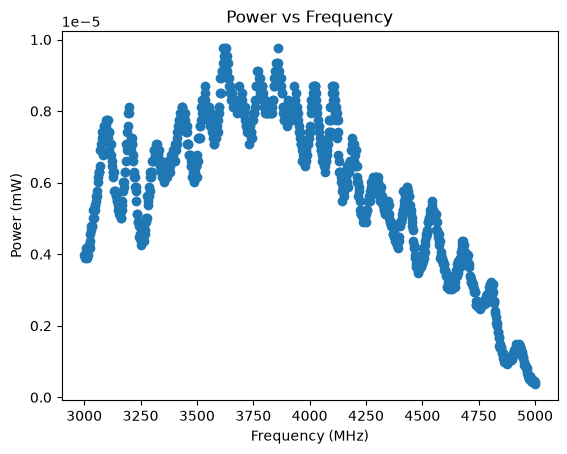

In [7]:
plt.title("Power vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")

plt.scatter(frequency, power_mW)

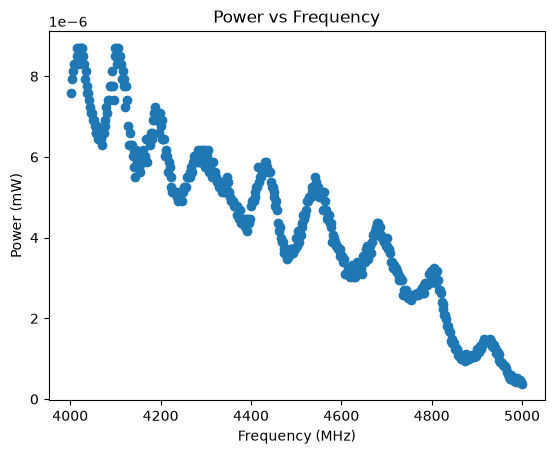

In [8]:
mask = frequency > 4000
frequency_trimmed = frequency[mask]
power_mW_trimmed = power_mW[mask]

plt.title("Power vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")

plt.scatter(frequency_trimmed, power_mW_trimmed)

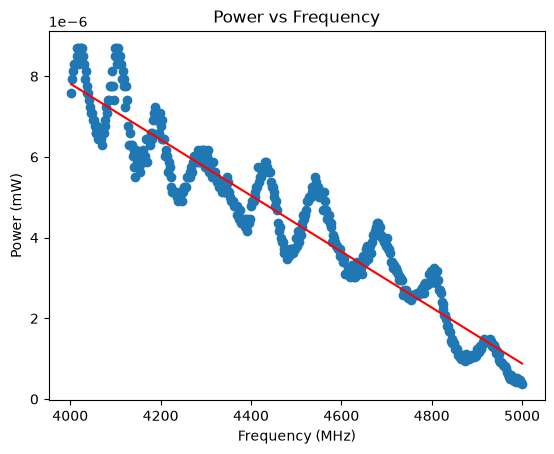

In [9]:
def linear_fit(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_fit, frequency_trimmed, power_mW_trimmed, p0=(-1, 40e-6))
perr = np.sqrt(np.diag(pcov))

plt.title("Power vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")

plt.scatter(frequency_trimmed, power_mW_trimmed)
plt.plot(frequency_trimmed, linear_fit(frequency_trimmed, popt[0], popt[1]), color = 'red')
plt.show()